# Генерация поэзии с помощью нейронных сетей: шаг 1
Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [1]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [2]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

seed = 777

np.random.seed(seed)
# Устанавливаем seed для CPU генератора случайных чисел PyTorch
torch.manual_seed(seed)

# Если используете CUDA, устанавливаем seed для GPU генератора
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed )
    torch.cuda.manual_seed_all(seed)

# Для полной воспроизводимости также можно зафиксировать алгоритмы cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


cuda device is available


## 1. Загрузка данных.

Загрузим текст.

In [3]:
# do not change the code in the block below
# __________start of block__________
# !wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
    
with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()
    
text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

## 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [4]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

# Проверка количества токенов
assert num_tokens == 84, "Check the tokenization process"

# Сопоставление токенов их номерам и обратно
token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

# Проверка уникальности и равенства сопоставлений
assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")

# токенизируем текст
text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


`tokens` - количество никальных токенов (символов в тесте)    
`token_to_idx` - словарь сопоставление токена его номеру    
`idx_to_token` - обратный словать сопоставления номера токена самому токену    
`text_encoded` - закодированный текст    

__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [5]:
# do not change the code in the block below
# __________start of block__________
batch_size = 1  # Было 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________    

Пример батча:

In [7]:
print(next(generate_chunk()))

print(next(generate_chunk()).shape)

[[83  1 48 56 76 49 53 63  1 78  1 53  1 62 50 61 49 67 50  1 47  1 58 50
  54  0 52 45 46 53 56 59 62 73  1 68 45 70 50  1 53  1 62 53 56 73 58 50
  54  7  0  0  0  0 40 38 26  0  0 50 50  1 62 59 57 58 50 58 53 76  1 62
  57 64 70 45 75 63 12  0 43 60 59 54 49 64  1 56 73  1 47 60 50 61 50 49
   5  1 60 59 54]]
(1, 101)


## 3. Обучение модели

Далее вам предстоит написать код для обучения модели и генерации текста.

In [ ]:
# your beautiful experiments here

### Определим  и инстанцируем модель

Модель имеет следующие параметры:    
`input_size` - входной размер модели, это количество возможных вариантов для каждого символа на входе RNN (равен размеру num_tokens).    
`hidden_size` -  подбирается эксперементально (выбирается в диапазоне от 32 до 512)    
`output_size` - это количество нейронов на выходном слое RNN. Каждый нейрон отвечает за вероятность появления определенного символа (равен размеру num_tokens).     
`n_layers` - количество слоёв, подбирается эксперементально (обычно от 1 до 3)    


In [8]:
from torch.autograd import Variable

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(RNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        
        self.encoder = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hidden):
        input = self.encoder(input.view(1, -1))
        output, hidden = self.gru(input.view(1, 1, -1), hidden)
        output = self.decoder(output.view(1, -1))
        return output, hidden

    def init_hidden(self):
        return Variable(torch.zeros(self.n_layers, 1, self.hidden_size))


hidden_size = 256  # Размер скрытого состояния
input_size = num_tokens  # Размер входа
output_size = num_tokens  # Размер выхода
num_layers = 2  # Количество слоев RNN


model = RNN(hidden_size, hidden_size, output_size, n_layers=1).to(device)


In [55]:
n_iters = 1

for iter in range(1, n_iters + 1):
    for i, chunk in enumerate(generate_chunk()):
        print(i, chunk.shape)
        for 

SyntaxError: invalid syntax (2526957367.py, line 6)

In [9]:
torch.backends.cudnn.benchmark = True

In [ ]:
def train(model, optimizer, criterion, n_iters=1000, print_every=100, plot_every=10):
    current_loss = 0
    all_losses = []

    for iter in range(1, n_iters + 1):
        
        # optimizer.zero_grad()
        for param in model.parameters():
            param.grad = None

        loss = 0
        hidden = model.init_hidden().to(device)
        model.train()

        for i, chunk in enumerate(generate_chunk()):

            chunk = torch.from_numpy(chunk).to(device)
            for j in range(chunk.shape[1] - 1):
                input = chunk[:, j]
                target = chunk[:, j + 1]
                output, hidden = model(input, hidden)
                loss += criterion(output, target)

        loss.backward()

        if iter % print_every == 0:
            print('Iter: {}; Loss: {:.3f}'.format(iter, loss.item() / seq_length), "current learning rate:", optimizer.param_groups[0]['lr'])

        if iter % plot_every == 0:
            all_losses.append(current_loss / plot_every)
            current_loss = 0

        optimizer.step()
        scheduler.step()
        
        current_loss += loss.item() / seq_length

    return all_losses

lr = 1e-3
n_iters = 5000

# Используем оптимизатор и shedulet чтобы плавно линейно уменьшать learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.9)
criterion = nn.CrossEntropyLoss()

all_losses = train(model, optimizer, criterion, n_iters, print_every=100, plot_every=10)

Iter: 100; Loss: 2.664 current learning rate: 0.001
Iter: 200; Loss: 2.355 current learning rate: 0.001
Iter: 300; Loss: 2.333 current learning rate: 0.001
Iter: 400; Loss: 2.363 current learning rate: 0.001
Iter: 500; Loss: 2.169 current learning rate: 0.001
Iter: 600; Loss: 2.327 current learning rate: 0.0009000000000000001
Iter: 700; Loss: 2.062 current learning rate: 0.0009000000000000001
Iter: 800; Loss: 2.296 current learning rate: 0.0009000000000000001
Iter: 900; Loss: 1.936 current learning rate: 0.0009000000000000001
Iter: 1000; Loss: 2.119 current learning rate: 0.0009000000000000001
Iter: 1100; Loss: 2.026 current learning rate: 0.0008100000000000001
Iter: 1200; Loss: 2.105 current learning rate: 0.0008100000000000001
Iter: 1300; Loss: 1.988 current learning rate: 0.0008100000000000001
Iter: 1400; Loss: 1.987 current learning rate: 0.0008100000000000001
Iter: 1500; Loss: 2.121 current learning rate: 0.0008100000000000001
Iter: 1600; Loss: 2.117 current learning rate: 0.00072

In [13]:
all_losses[0:10]

[3.704204986572266,
 3.324873260498047,
 3.0421267700195314,
 2.8643921508789063,
 2.8947293090820314,
 2.7274389038085936,
 2.732170715332031,
 2.7167321166992187,
 2.6544290924072262,
 2.599137649536133]

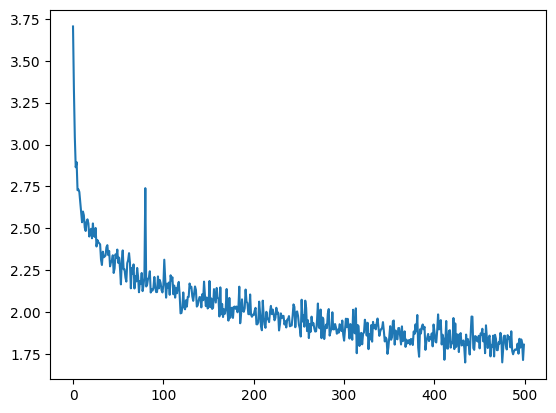

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

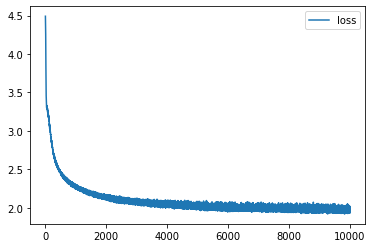

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [ ]:
def evaluate(prime_str='A', predict_len=100, temperature=0.8):
    hidden = decoder.init_hidden()
    prime_input = char_tensor(prime_str)
    predicted = prime_str

    # Use priming string to "build up" hidden state
    for p in range(len(prime_str) - 1):
        _, hidden = decoder(prime_input[p], hidden)
    inp = prime_input[-1]
    
    for p in range(predict_len):
        output, hidden = decoder(inp, hidden)
        
        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]
        
        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        inp = char_tensor(predicted_char)

    return predicted

In [ ]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    
    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)
    
    #feed the seed phrase, if any
            
    # your code here
    
    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

In [ ]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    
    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)
    
    hidden = char_rnn.init_hidden()
    tensor = torch.tensor


    
    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [15]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                         smaller temperature converges to the single most likely output
    '''

    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)

    #feed the seed phrase, if any
    hidden = char_rnn.init_hidden().to(device)
    for i in range(len(seed_phrase) if seed_phrase is not None else 0):
        output, hidden = char_rnn(x_sequence[:, i], hidden)

    #start generating
    for i in range(len(seed_phrase) if seed_phrase is not None else 0, max_length):
        output, hidden = char_rnn(x_sequence[:, -1], hidden)
        
        # sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]

        # Add predicted character to string and use as next input
        predicted_char = idx_to_token[top_i.item()]
        x_sequence = torch.cat((x_sequence, torch.tensor([[top_i]], dtype=torch.int64).to(device)), dim=1)

        if predicted_char == '<eos>':
            break

    return ''.join([idx_to_token[ix] for ix in x_sequence.cpu().data.numpy()[0]])

In [17]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

<sos> мой дядя самых честных правилась,
set tale tal-atteta benemefумарь решить,
вот говорил его деле
темне требеждь пеней, давно чтом надежды,
я точно лежды, глуют,
и блесиновны любовню:
другеч ли, напостался реко,
и задконец какает он
давними межны многий;
но теперь меж быть ее слажеет субом
бланивы без момнит.



xxviiii

недословить не всё гольбовник,
она в глубоки окними верно
в очердачный с письмо замелы
часта печаляний ближ?» – «такая бог
нем отприятных суждений,
она и гаринеты,
и хоть легке т


## Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [24]:
seed_phrase = ' мой дядя самых честных правил'

In [18]:
# generated_phrases = # your code here

# For example:

generated_phrases = [
    generate_sample(
        model,
        ' мой дядя самых честных правил',
        max_length=500,
        temperature=1.
    ).replace('<sos>', '')
    for _ in range(10)
]

generated_phrases

[' мой дядя самых честных правила».\n\n\n\nxlii\n\nно его наше желье в эта.\nктяют понять постел лечной\nи   ему душом отдал…\nв осамитакины и дображу\nя вне эту ее преждал он.\nздатом вкланный проте он:\nа ты вучинут и злака\nна за москливой на обли\n– тот онегин учем изловы\nмой долаца, брозенья, на молчиты!,\nу столи повидел отворила.\nв шумуке уль…» уж б слетам,\n гремен был яснетам, poracure – ревною\nза не ум сень,\nон колевеной холялась\nголоно во всегда всё красстяю,\nодном ленский дересут.\nо вас ее судь ототям',
 ' мой дядя самых честных правилась\nсожась на чуда огнула,\nполней пором набреоты пречужу;\nза мне впо в еблася поточет\nи вмугине гузурки мадра,\nпротояны, ходемный предани,\nи пылакя, томногда миру.\nи все дыми татьяну посодрался,\nсветоне, сердосил узолом,\nстрепен и чем к товь, сей старой\nи к-оняжке сомнетно, богах!\nона сон не свою ученееь.\nпоскольней сед тваясные года,\nбутык он ромал он зеловой,\nв лежка приветок начных другой,\nонегин встей все свираствился

In [19]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'
    

submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

File saved to `submission_dict.json`


На этом задание завершено. Поздравляем!